# sample5 - コールバック（EarlyStopping・ModelCheckpoint）

Keras の **コールバック** は学習中に自動で処理を行う仕組みです。  
過学習防止・モデル保存・学習率調整などを自動化できます。

| ステップ | 内容 |
|----------|------|
| 1 | EarlyStopping（過学習で自動停止） |
| 2 | ModelCheckpoint（最良モデルを保存） |
| 3 | ReduceLROnPlateau（学習率自動調整） |
| 4 | 複数コールバックの組み合わせ |

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # GPU を無効化して CPU で実行
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
print("TensorFlow:", tf.__version__)

# データ準備
housing = fetch_california_housing()
X, y = housing.data, housing.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

print("データ準備完了")

I0000 00:00:1771826958.508215  137402 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1771826959.444553  137402 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.22.0-dev20260222
データ準備完了


## 1. EarlyStopping

検証 Loss が改善しなくなったら自動で学習を停止します。  
`patience` は何エポック待つかの設定です。

In [2]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',  # 監視する指標
    patience=10,         # 10エポック改善なければ停止
    restore_best_weights=True  # 最良の重みに戻す
)

model1 = build_model()
history1 = model1.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=0
)
print(f"実際の学習エポック数: {len(history1.history['loss'])} / 200")

/home/user/HOME/sample/sample_python/403_TensorFlowKeras/env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


実際の学習エポック数: 92 / 200


## 2. ModelCheckpoint

最良のモデルをファイルに保存します。学習が途中で止まっても最良モデルが残ります。

In [3]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_model.keras',  # 保存先
    monitor='val_loss',
    save_best_only=True,          # 最良モデルだけ保存
    verbose=1
)

model2 = build_model()
history2 = model2.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[checkpoint],
    verbose=0
)

# 保存されたモデルを読み込む
best_model = tf.keras.models.load_model('best_model.keras')
print("保存済みモデルの読み込み完了")


Epoch 1: val_loss improved from None to 0.47159, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras

Epoch 2: val_loss improved from 0.47159 to 0.42379, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras

Epoch 3: val_loss improved from 0.42379 to 0.39201, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras

Epoch 4: val_loss improved from 0.39201 to 0.38167, saving model to best_model.keras

Epoch 4: finished saving model to best_model.keras

Epoch 5: val_loss improved from 0.38167 to 0.37279, saving model to best_model.keras

Epoch 5: finished saving model to best_model.keras

Epoch 6: val_loss improved from 0.37279 to 0.35781, saving model to best_model.keras

Epoch 6: finished saving model to best_model.keras

Epoch 7: val_loss improved from 0.35781 to 0.35619, saving model to best_model.keras

Epoch 7: finished saving model to best_model.keras

Epoch 8: val_loss improved from 0.35

## 3. ReduceLROnPlateau

Loss が改善しなくなったら学習率を自動で下げます。

In [4]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,    # 学習率を半分に
    patience=5,
    min_lr=1e-6,
    verbose=1
)

model3 = build_model()
history3 = model3.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[reduce_lr],
    verbose=0
)
print("学習完了")


Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 62: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 78: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 93: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 98: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
学習完了


## 4. 複数コールバックの組み合わせ・可視化

/tmp/ipykernel_137402/1879425177.py:28: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_137402/1879425177.py:28: UserWarning: Glyph 12456 (\N{KATAKANA LETTER E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_137402/1879425177.py:28: UserWarning: Glyph 12509 (\N{KATAKANA LETTER PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_137402/1879425177.py:28: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_137402/1879425177.py:28: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_137402/1879425177.py:28: UserWarning: Glyph 12391 (\N{HIRAGANA LETTER DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_137402/1879425177.py:28: UserWarning: Glyph 20572 (\N{CJK UNIFIED IDEOGRAPH-505C}) missing from font(s

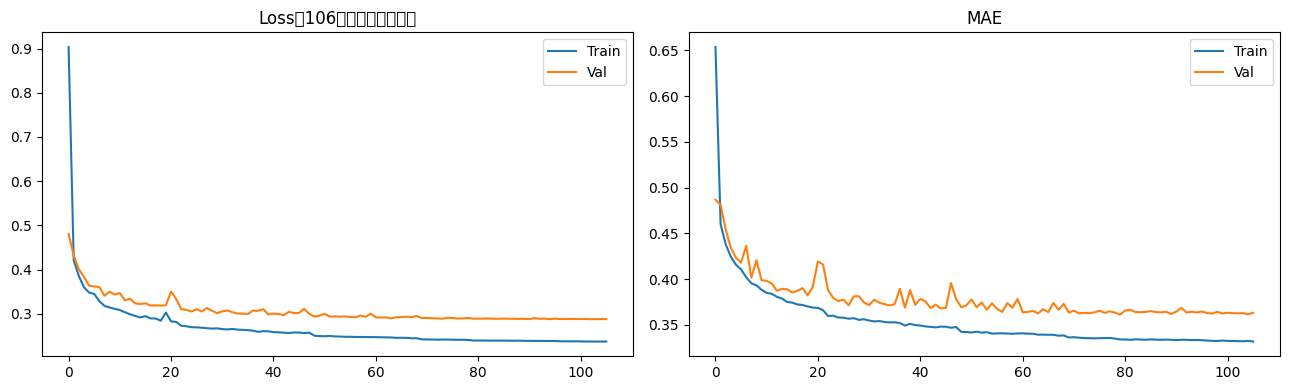

In [5]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('best_combined.keras', monitor='val_loss', save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

model4 = build_model()
history4 = model4.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=0
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history4.history['loss'],     label='Train')
axes[0].plot(history4.history['val_loss'], label='Val')
axes[0].set_title(f"Loss（{len(history4.history['loss'])}エポックで停止）")
axes[0].legend()

axes[1].plot(history4.history['mae'],     label='Train')
axes[1].plot(history4.history['val_mae'], label='Val')
axes[1].set_title('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()